# GMKG Path


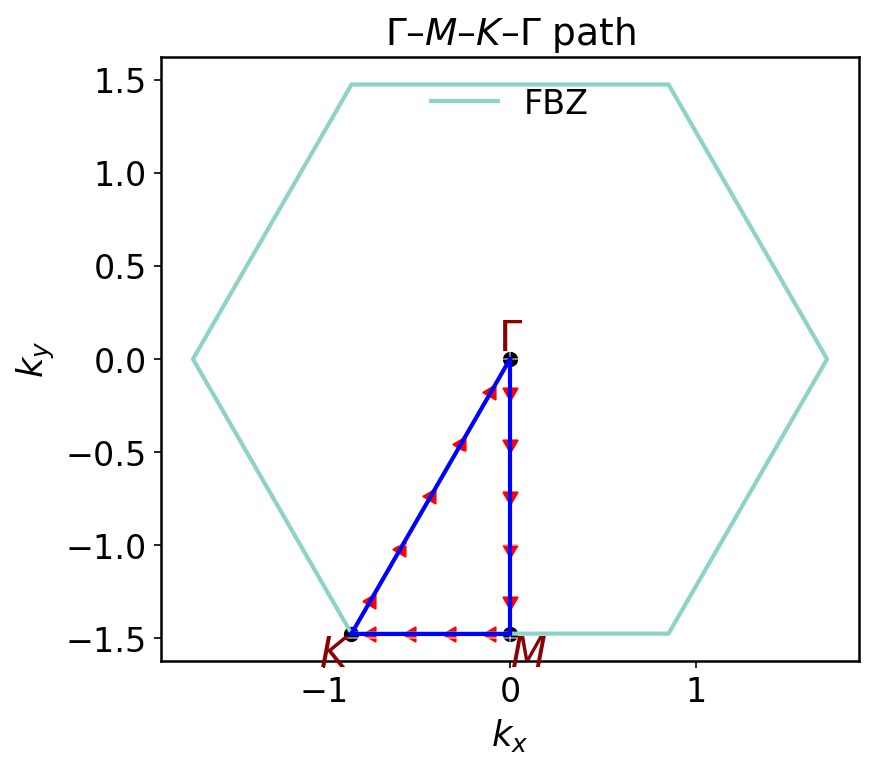

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from common.mpl_style import set_mpl_style
set_mpl_style()

# -----------------------------
# 1) Real-space primitive vectors for graphene's Bravais lattice (triangular)
# -----------------------------
a = 2.46  # lattice constant sets scale only
a1 = a * np.array([1.0, 0.0])
a2 = a * np.array([0.5, np.sqrt(3)/2])

# -----------------------------
# 2) Reciprocal lattice from first principles: a_i · b_j = 2π δ_ij
# -----------------------------
A = np.column_stack([a1, a2])            # 2x2 matrix with columns a1, a2
B = 2*np.pi * np.linalg.inv(A).T         # columns are b1, b2
b1 = B[:, 0]
b2 = B[:, 1]

# -----------------------------
# Polygon clipping by half-planes: n·k <= c
# (Sutherland–Hodgman style for convex polygons)
# -----------------------------
def clip_polygon_halfplane(poly, n, c, eps=1e-12):
    """
    Clip a convex polygon by the half-plane n·x <= c.
    poly: (N,2) vertices in CCW order
    returns clipped polygon vertices in CCW order
    """
    def inside(p):
        return np.dot(n, p) <= c + eps

    def intersection(p1, p2):
        # line segment p(t)=p1+t(p2-p1), find t s.t. n·p(t)=c
        d = p2 - p1
        denom = np.dot(n, d)
        if abs(denom) < eps:
            return p2  # segment ~parallel; shouldn't matter if well-posed
        t = (c - np.dot(n, p1)) / denom
        return p1 + t*d

    if len(poly) == 0:
        return poly

    out = []
    prev = poly[-1]
    prev_in = inside(prev)

    for curr in poly:
        curr_in = inside(curr)
        if curr_in:
            if not prev_in:
                out.append(intersection(prev, curr))
            out.append(curr)
        else:
            if prev_in:
                out.append(intersection(prev, curr))
        prev, prev_in = curr, curr_in

    return np.array(out)

# -----------------------------
# 3) Build FBZ as intersection of half-planes: k·G <= |G|^2/2 for many G != 0
# -----------------------------
def compute_fbz(b1, b2, G_range=3, R0=50.0):
    """
    Compute the first Brillouin zone (Wigner–Seitz cell around Gamma)
    by intersecting half-planes against reciprocal lattice points G = m b1 + n b2.
    G_range controls how many G's to include; >=2 is usually enough.
    R0 is the initial bounding polygon radius.
    """
    # Start with a large square polygon (CCW)
    poly = np.array([
        [-R0, -R0],
        [ R0, -R0],
        [ R0,  R0],
        [-R0,  R0],
    ], dtype=float)

    # Generate reciprocal lattice points (exclude G=0)
    Gs = []
    for m in range(-G_range, G_range+1):
        for n in range(-G_range, G_range+1):
            if m == 0 and n == 0:
                continue
            G = m*b1 + n*b2
            Gs.append(G)
    Gs = np.array(Gs)

    # Sort by |G| (closest constraints first -> more stable)
    norms = np.linalg.norm(Gs, axis=1)
    Gs = Gs[np.argsort(norms)]

    # Clip polygon by each WS inequality
    for G in Gs:
        n = G
        c = 0.5 * np.dot(G, G)
        poly = clip_polygon_halfplane(poly, n, c)
        if len(poly) == 0:
            raise RuntimeError("Polygon vanished; increase R0 or check lattice vectors.")
    return poly

fbz = compute_fbz(b1, b2, G_range=4, R0=100.0)

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# (Reuse everything from the previous script up to `fbz`)
# ============================================================

# --- Close polygon and ensure CCW ordering ---
fbz = np.array(fbz)
center = fbz.mean(axis=0)
angles = np.arctan2(fbz[:,1] - center[1], fbz[:,0] - center[0])
fbz = fbz[np.argsort(angles)]
fbz_closed = np.vstack([fbz, fbz[0]])

# ============================================================
# Γ–M–K–Γ path with chevron direction markers
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Identify Γ, K, M from FBZ geometry
# -----------------------------
Gamma = np.array([0.0, 0.0])

# choose one K as a vertex (consistent with your previous choice)
K = fbz[0]
K_next = fbz[1]
M = 0.5 * (K + K_next)

# -----------------------------
# Helper: plot a segment with chevrons ">"
# -----------------------------
def plot_segment_with_chevrons(p, q, n=5, pad=0.12, size=60):
    """
    Plot segment p -> q with chevrons indicating direction.
    """
    p = np.asarray(p)
    q = np.asarray(q)

    # draw the segment line
    plt.plot([p[0], q[0]], [p[1], q[1]], linewidth=2, color='blue')

    # positions for chevrons (avoid endpoints)
    ts = np.linspace(pad, 1 - pad, n)
    xs = p[0] + ts * (q[0] - p[0])
    ys = p[1] + ts * (q[1] - p[1])

    # direction angle (from +kx axis)
    alpha = np.degrees(np.arctan2(q[1] - p[1], q[0] - p[0]))

    # IMPORTANT: triangle marker points along +ky at 0°, so shift by -90°
    theta = alpha - 90.0

    plt.scatter(xs, ys, marker=(3, 0, theta), s=size, color='red')

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 6))

# FBZ
plt.plot(fbz_closed[:, 0], fbz_closed[:, 1], linewidth=2, label="FBZ")

# Γ–M–K–Γ path with chevrons
plot_segment_with_chevrons(Gamma, M)
plot_segment_with_chevrons(M, K, n=4)
plot_segment_with_chevrons(K, Gamma)

# Mark special points
plt.scatter(*Gamma, s=40, color='black')
plt.text(*Gamma, r"$\Gamma$", ha="center", va="bottom", fontsize=20, color='darkred')

plt.scatter(*M, s=40, color='black')
plt.text(*M, r"$M$", ha="left", va="top", fontsize=20, color='darkred')

plt.scatter(*K, s=40, color='black')
plt.text(*K, r"$K$", ha="right", va="top", fontsize=20, color='darkred')

# Cosmetics
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title(r"$\Gamma$–$M$–$K$–$\Gamma$ path")
plt.grid(True)
plt.legend()
plt.savefig('./graphics_out/gmkg_path.png', dpi=500)
plt.show()
